## Using nuclei-binned data

Instead of running the analysis on 2um bins directly, we now use 2um bins that are aggregated on segmented nuclei.

In [ ]:
import spatialdata as sd
import spatialdata_io
import spatialdata_plot
import sparrow as sp
from sparrow.io._visium_hd import visium_hd
import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import _rasterize_bins from ../utils/rasterize_bins.py
import sys
sys.path.append('../utils')
from rasterize_bins import _rasterize_bins

/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribut

In [ ]:
sc.set_figure_params(facecolor="white", figsize=(8, 8))
sc.settings.n_jobs = 8
sc.settings.verbosity = 3
sc.settings.figdir = "./plots"

In [2]:
sdata = sd.read_zarr('../data/Visium_HD_Liver/Visium_HD_Liver_zarr')

/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:

In [4]:
first_run = False

if first_run:
    # bin barcodes to the segmentation masks
    sdata = sp.tb.bin_counts( 
        sdata,
        table_layer="square_002um",
        labels_layer="segmentation_mask",
        output_layer="table_002um_stardist_segmentation",
        append=False,
        overwrite=True,
    )
    
    # Convert table to csc instead of csr
    table_layer = "table_002um_stardist_segmentation"
    adata = sdata[table_layer]
    adata.X = adata.X.tocsc()
    del sdata[table_layer]
    sdata.delete_element_from_disk(table_layer)
    sdata[table_layer] = adata
    sdata.write_element(table_layer)

## QC and preprocessing

We perform some basic filtering of spots based on total counts and expressed genes on the 8um bin

In [5]:
adata = sdata['table_002um_stardist_segmentation']
adata

AnnData object with n_obs × n_vars = 140844 × 19059
    obs: 'cell_ID', 'fov_labels'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

In [6]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)

In [7]:
# Remove the only 'cell' that encompasses the whole area?
sc.pp.filter_cells(adata, max_counts=33569000.0)

filtered out 1 cells that have more than 33569000.0 counts


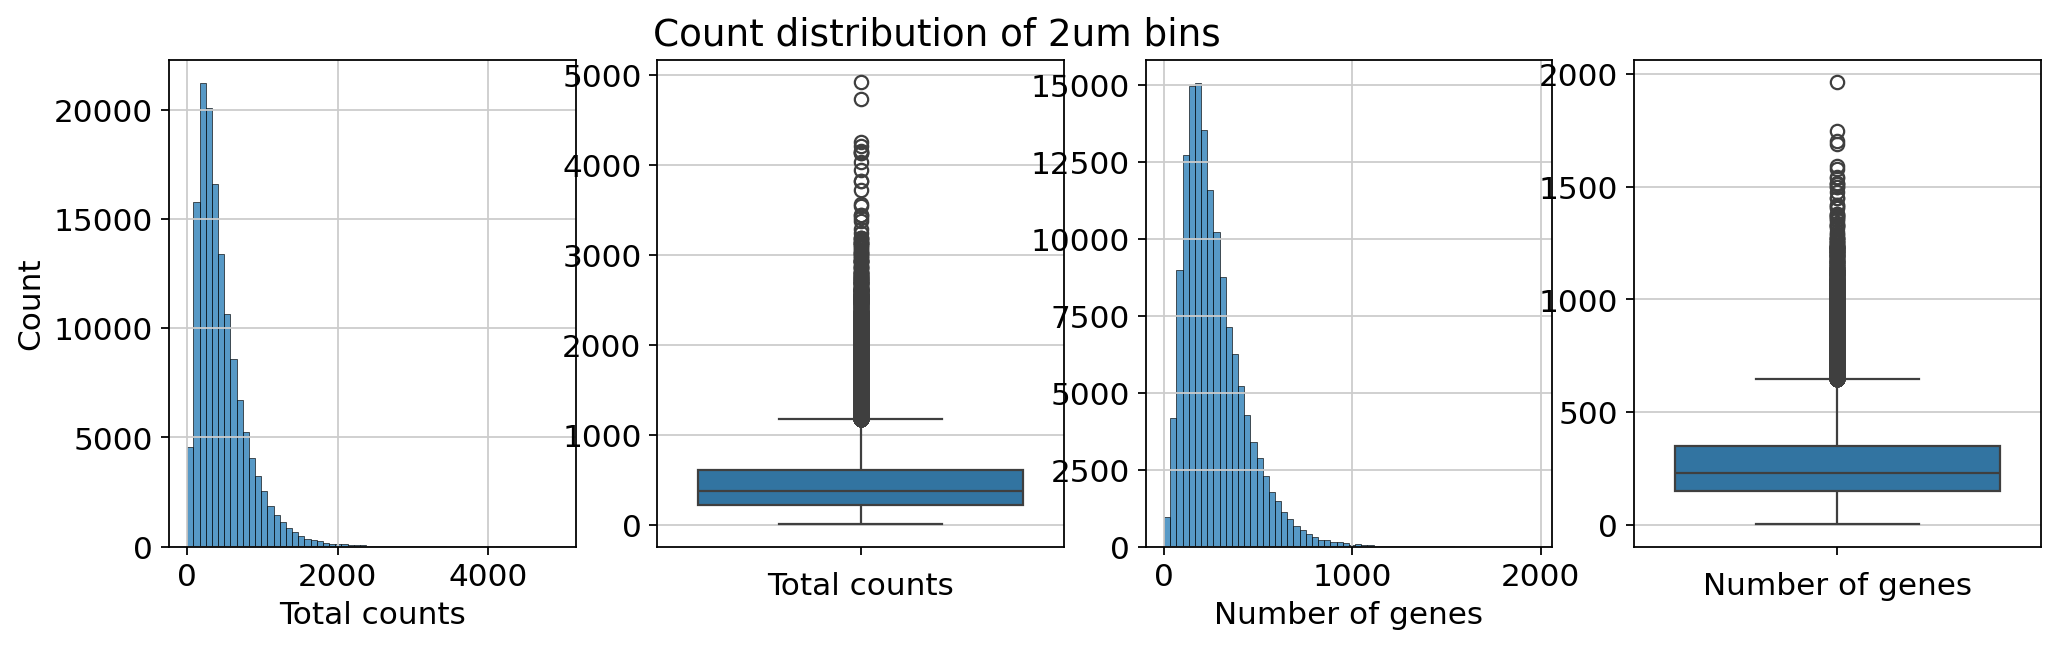

In [9]:
fig, axs = plt.subplots(1, 4, figsize=(15, 4))
sns.histplot(adata.obs["total_counts"], kde=False, bins=60, ax=axs[0])
sns.boxplot(adata.obs["total_counts"], ax=axs[1])
sns.histplot(adata.obs["n_genes_by_counts"], kde=False, bins=60, ax=axs[2])
sns.boxplot(adata.obs["n_genes_by_counts"], ax=axs[3])

# Set overall title
fig.suptitle("Count distribution of 2um bins")

# Set title and labels
axs[0].set_xlabel("Total counts")
axs[1].set_xlabel("Total counts")
axs[2].set_xlabel("Number of genes")
axs[3].set_xlabel("Number of genes")

# Turn off y-axis title
axs[1].set_ylabel("")
axs[2].set_ylabel("")
axs[3].set_ylabel("")

# Save plot
plt.savefig("plots/histogram_count_genes_2um_binned.png", dpi=300)


In [10]:
# sc.pp.filter_cells(adata, min_counts=50)
sc.pp.filter_cells(adata, max_counts=4500)
print(f"#cells before MT filter: {adata.n_obs}")
adata = adata[adata.obs["pct_counts_mt"] < 20].copy()
print(f"#cells after MT filter: {adata.n_obs}")
sc.pp.filter_genes(adata, min_cells=10)

filtered out 2 cells that have more than 4500 counts
#cells before MT filter: 140841
#cells after MT filter: 140841
filtered out 5987 genes that are detected in less than 10 cells


We proceed to normalize Visium counts data with the built-in `normalize_total` method from Scanpy, and detect highly-variable genes (for later). Note that there are alternatives for normalization (see discussion in [[Luecken19](https://www.embopress.org/doi/full/10.15252/msb.20188746)], and more recent alternatives such as [SCTransform](https://genomebiology.biomedcentral.com/articles/10.1186/s13059-019-1874-1) or [GLM-PCA](https://genomebiology.biomedcentral.com/articles/10.1186/s13059-019-1861-6)).

In [11]:
adata.layers["counts"] = adata.X.copy()

In [12]:
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, flavor="seurat", n_top_genes=2000)

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


## Manifold embedding and clustering based on transcriptional similarity

To embed and cluster the manifold encoded by transcriptional similarity, we proceed as in the standard clustering tutorial.

In [14]:
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(
    adata, key_added="clusters", flavor="igraph", directed=False, n_iterations=2
)

computing PCA
    with n_comps=50
    finished (0:00:05)
computing neighbors
    using 'X_pca' with n_pcs = 50


/home/chananchidas/miniconda3/envs/harpy2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:24)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:01:38)
running Leiden clustering
    finished: found 7 clusters and added
    'clusters', the cluster labels (adata.obs, categorical) (0:00:06)


We plot some covariates to check if there is any particular structure in the UMAP associated with total counts and detected genes.

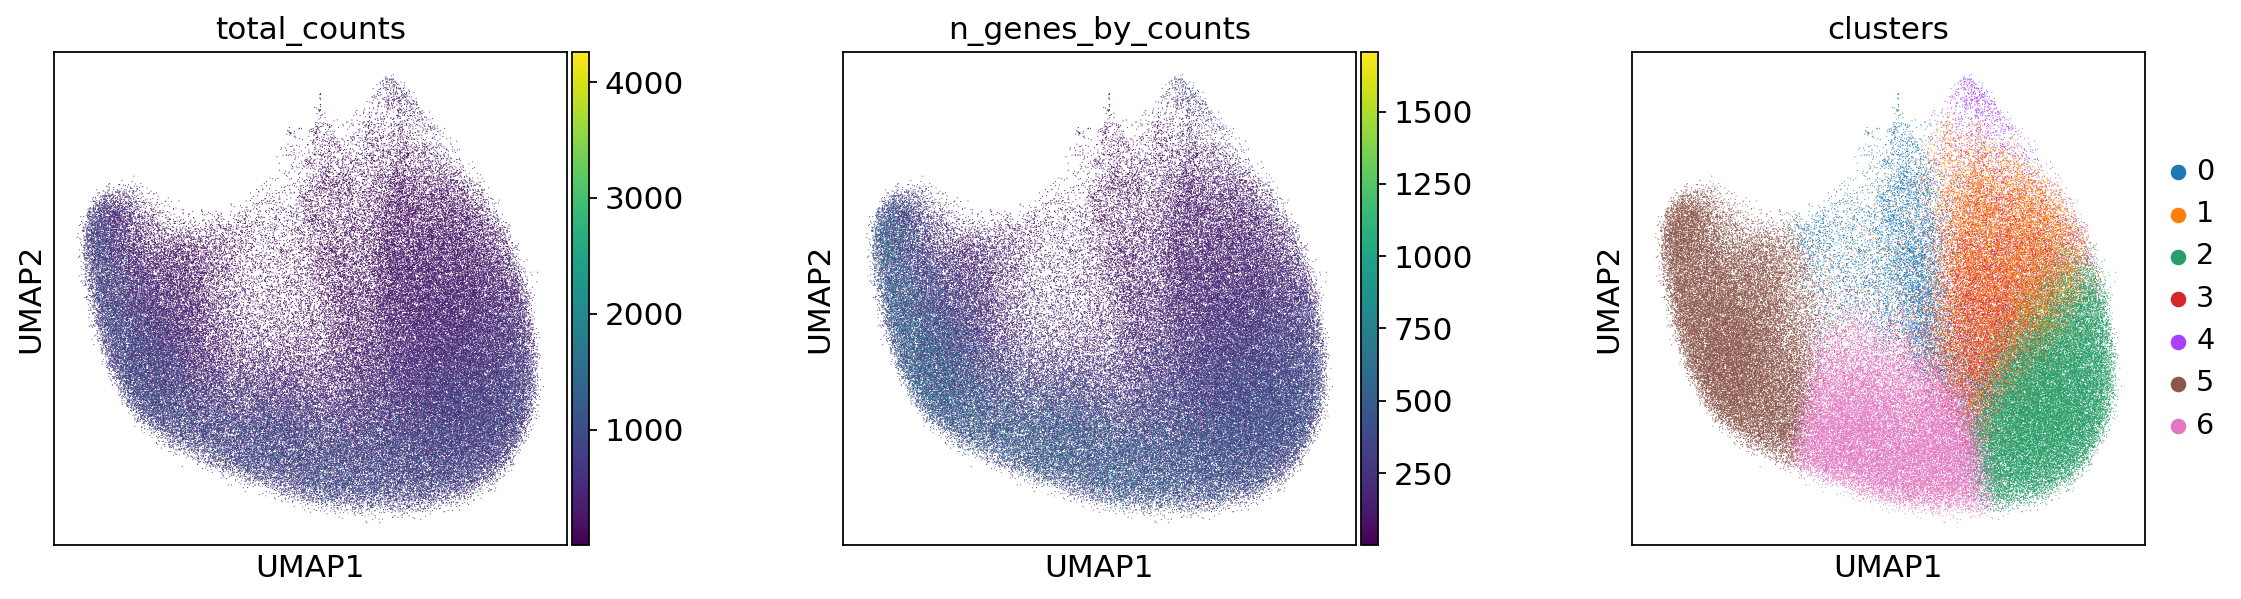

In [15]:
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.umap(adata, color=["total_counts", "n_genes_by_counts", "clusters"], wspace=0.4)

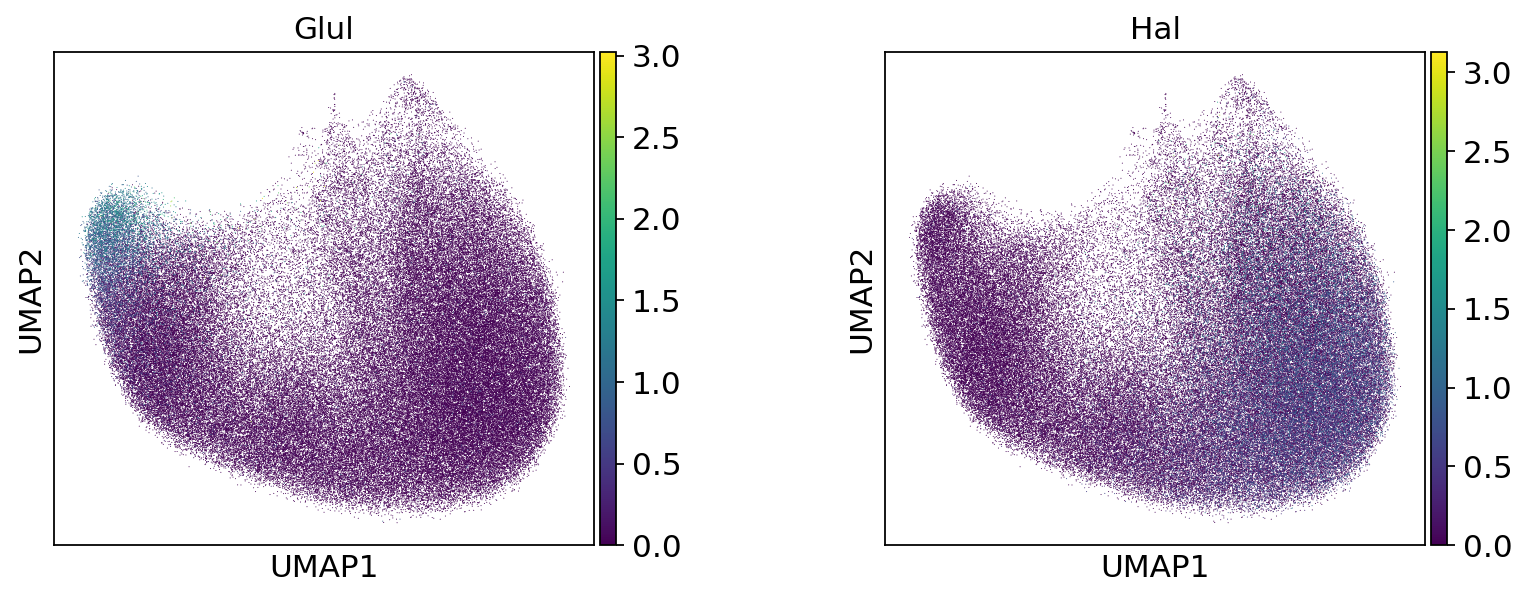

In [16]:
# Plot some liver zonation markers
zonation_markers = ['Glul', 'Hal']
sc.pl.umap(adata, color=zonation_markers, wspace=0.4)

In [ ]:
sdata['table_002um_stardist_segmentation_pp'] = adata
sdata.write_element('table_002um_stardist_segmentation_pp')

## Visualization in spatial coordinates

Let us now take at the leiden clusters spatially. We will overlay the circular spots on top of the Hematoxylin and eosin stain (H&E) image provided.

In [10]:
adata = sdata.tables['table_002um_stardist_segmentation_pp']
labels_layer = "segmentation_mask"

2025-02-03 16:14:16,185 - sparrow.plot._plot - WARNING - There are '122' cells in provided shapes_layer 'segmentation_boundaries' not found in 'sdata.tables[table_002um_stardist_segmentation_pp]' (linked through 'cell_ID'), these cells will not be plotted.


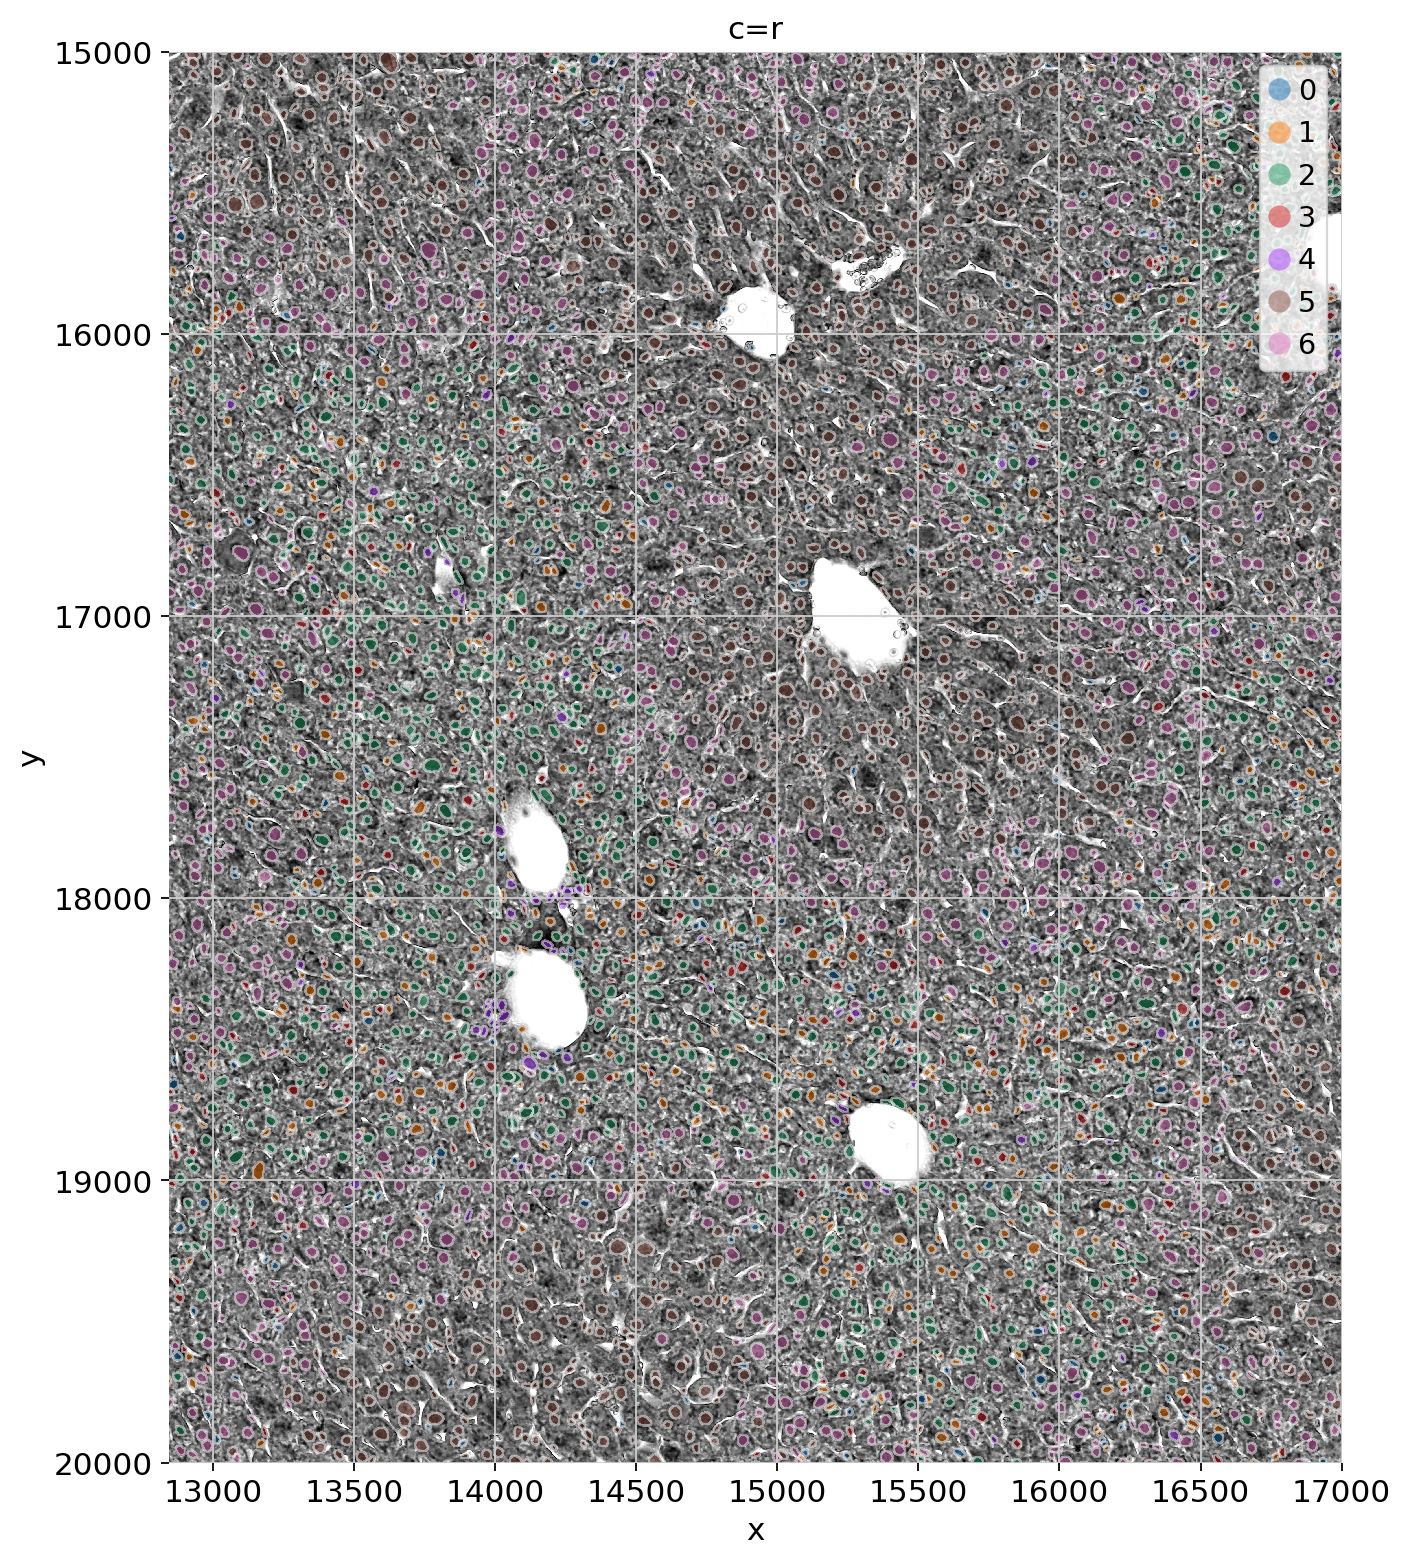

In [ ]:
# sanity plot
sp.pl.plot_shapes(
    sdata, 
    #labels_layer="segmentation_mask",
    img_layer="Visium_HD_Liver_full_image",
    column="clusters",
    table_layer="table_002um_stardist_segmentation_pp",
    shapes_layer="segmentation_boundaries",
    crd=[12844, 17000, 15000, 20000],
    figsize=(10,10),
    channel="r",
    alpha=0.5
      )

## Cluster marker genes

Compute marker genes and plot a heatmap with expression levels of its top 10 marker genes across clusters.

In [11]:
adata = sdata.tables['table_002um_stardist_segmentation_celltype_scores']

In [12]:
adata

AnnData object with n_obs × n_vars = 140841 × 13072
    obs: 'cell_ID', 'fov_labels', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'clusters', 'BCell', 'KC', 'LAM', 'LSEC', 'TCell', 'basophil', 'cDC1', 'cDC2', 'cholangiocyte', 'coreMacrophage', 'fibroblast', 'hepatocyte', 'monocyte', 'neutrophil', 'otherMacrophage', 'stellate', 'Cleanliness', 'annotation'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'clusters', 'clusters_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'spatialdata_attrs', 'umap', 'annotation_colors'
    obsm: 'X_pca', 'X_umap', 'spa

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:02)
categories: 0, 1, 2, etc.
var_group_labels: 5


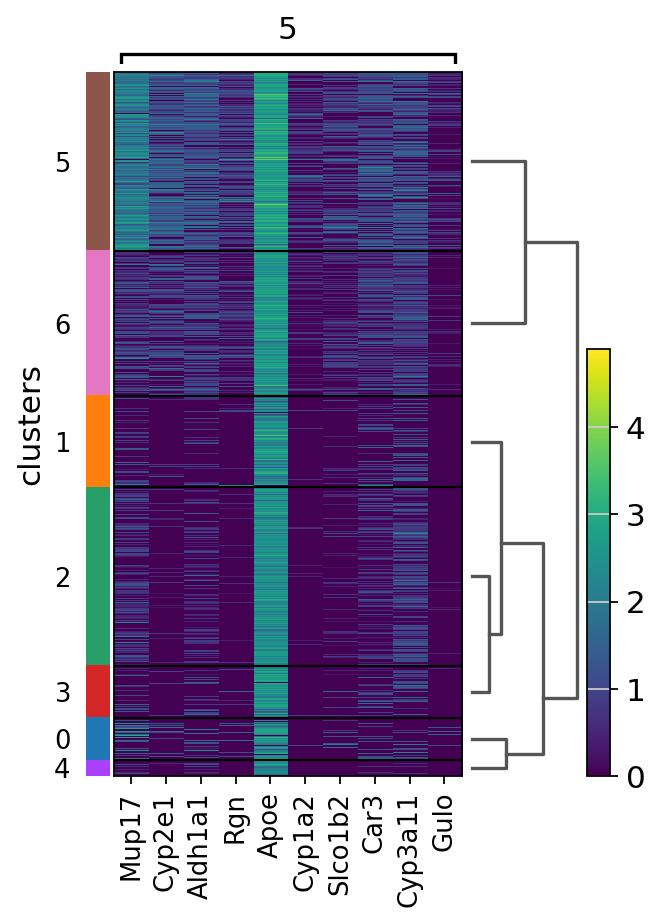

In [18]:
sc.tl.rank_genes_groups(adata, "clusters", method="t-test")
sc.pl.rank_genes_groups_heatmap(adata, groups="5", n_genes=10, groupby="clusters")